In [1]:
# ============================================================
# CELL 1: COMMON DEFINITIONS
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# ===========================
# Reproducibility
# ===========================
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ===========================
# Device
# ===========================
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
print('using device:', device)

# ===========================
# Model — plain Tanh 8x256
# ===========================
LAYERS  = 8
NEURONS = 256
N_FOURIER = 0
B_SCALE = 0

class PINN(nn.Module):
    def __init__(self, layers=LAYERS, neurons=NEURONS):
        super().__init__()
        net = [nn.Linear(3, neurons), nn.Tanh()]
        for _ in range(layers - 1):
            net += [nn.Linear(neurons, neurons), nn.Tanh()]
        net += [nn.Linear(neurons, 1)]
        self.net = nn.Sequential(*net)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

model = PINN().to(device)

# ===========================
# Hyperparameters
# ===========================
N_f          = 10000
N_i          = 5000
T_final      = 2 * np.pi
adam_epochs  = 20000
lbfgs_epochs = 500

w_pde      = 1.0
w_pde_slot = 5.0
w_ic       = 10.0
w_eik      = 0.0001

# ===========================
# Zalesak Geometry
# ===========================
XC, YC = 0.5, 0.75
R  = 0.15
W  = R / 6
L  = R

SLOT_YCENTER      = YC - 2 * W
SLOT_YMIN         = SLOT_YCENTER - L
SLOT_YMAX         = SLOT_YCENTER + L
SLOT_Y_LOCAL_CENTER = SLOT_YCENTER - YC
SLOT_Y_LOCAL_MIN  = SLOT_Y_LOCAL_CENTER - L
SLOT_Y_LOCAL_MAX  = SLOT_Y_LOCAL_CENTER + L

print(f'Disc : center=({XC},{YC}), R={R}')
print(f'Slot : X=[{XC-W:.4f},{XC+W:.4f}], Y=[{SLOT_YMIN:.4f},{SLOT_YMAX:.4f}]')

# ===========================
# Velocity Field
# ===========================
def velocity_field(x, y, t):
    u = -(y - 0.5)
    v =  (x - 0.5)
    return u, v

# ===========================
# Initial Condition
# ===========================
def initial_condition(x, y):
    phi_circle = torch.sqrt((x - XC)**2 + (y - YC)**2) - R
    slot_x     = torch.abs(x - XC) - W
    slot_y     = torch.abs(y - SLOT_YCENTER) - L
    phi_slot   = torch.maximum(slot_x, slot_y)
    return torch.maximum(phi_circle, -phi_slot)

# ===========================
# Sample Points
# ===========================
torch.manual_seed(100)
torch.cuda.manual_seed(100)

# --- Background collocation ---
X_f = torch.rand(N_f, 3, dtype=torch.float32, device=device).requires_grad_(True)

# --- Background IC ---
x_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
y_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
t_i = torch.zeros(N_i, 1, dtype=torch.float32, device=device)
X_i_base = torch.cat([x_i, y_i, t_i], dim=1)

# --- Slot bbox IC ---
N_slot = 2000
margin = 0.02
x_slot = (XC - W - margin) + (2*W + 2*margin) * torch.rand(N_slot, 1, device=device)
y_slot = (SLOT_YMIN - margin) + (2*L + 2*margin) * torch.rand(N_slot, 1, device=device)
t_slot = torch.zeros(N_slot, 1, device=device)
X_slot = torch.cat([x_slot, y_slot, t_slot], dim=1)

# --- Slot wall IC (phi=0 interface at t=0) ---
N_walls = 500
y_wall  = SLOT_YMIN + 2*L * torch.rand(N_walls, 1, device=device)
x_top   = (XC - W) + 2*W * torch.rand(N_walls, 1, device=device)
y_top   = torch.full((N_walls, 1), SLOT_YMAX, device=device)

X_walls = torch.cat([
    torch.cat([torch.full((N_walls,1), XC-W, device=device),
               y_wall.clone(), torch.zeros(N_walls,1,device=device)], dim=1),
    torch.cat([torch.full((N_walls,1), XC+W, device=device),
               y_wall.clone(), torch.zeros(N_walls,1,device=device)], dim=1),
    torch.cat([x_top, y_top,   torch.zeros(N_walls,1,device=device)], dim=1),
], dim=0)

X_i = torch.cat([X_i_base, X_slot, X_walls], dim=0).detach()

# --- Slot wall collocation (uniform t, all rotation angles) ---
N_f_slot_walls = 3000
np.random.seed(200)

t_sw    = np.random.rand(N_f_slot_walls)
theta   = 2 * np.pi * t_sw
cos_t   = np.cos(theta)
sin_t   = np.sin(theta)
XC_r    = 0.5 + cos_t*(XC-0.5) - sin_t*(YC-0.5)
YC_r    = 0.5 + sin_t*(XC-0.5) + cos_t*(YC-0.5)
side    = np.where(np.random.rand(N_f_slot_walls) > 0.5, -W, W)
yl      = SLOT_Y_LOCAL_MIN + 2*L * np.random.rand(N_f_slot_walls)
xg      = np.clip(XC_r + cos_t*side - sin_t*yl, 0.0, 1.0)
yg      = np.clip(YC_r + sin_t*side + cos_t*yl, 0.0, 1.0)

X_f_slot_walls = torch.tensor(
    np.stack([xg, yg, t_sw], axis=1),
    dtype=torch.float32, device=device
)

# --- Slot bottom collocation (biased toward t=0.5, 0.75, 1.0) ---
N_f_bottom = 3000
np.random.seed(300)
t_uniform_bot = np.random.rand(N_f_bottom // 2)
t_biased_bot  = np.concatenate([
    np.random.normal(0.50, 0.08, N_f_bottom // 6).clip(0, 1),
    np.random.normal(0.75, 0.08, N_f_bottom // 6).clip(0, 1),
    np.random.normal(1.00, 0.08, N_f_bottom // 6).clip(0, 1),
])
t_bot = np.concatenate([t_uniform_bot, t_biased_bot])
np.random.shuffle(t_bot)
theta_bot = 2 * np.pi * t_bot
cos_bot = np.cos(theta_bot);  sin_bot = np.sin(theta_bot)
XC_bot = 0.5 + cos_bot*(XC-0.5) - sin_bot*(YC-0.5)
YC_bot = 0.5 + sin_bot*(XC-0.5) + cos_bot*(YC-0.5)
xl_bot = -W + 2*W * np.random.rand(N_f_bottom)
yl_bot = np.full(N_f_bottom, SLOT_Y_LOCAL_MIN)
xg_bot = np.clip(XC_bot + cos_bot*xl_bot - sin_bot*yl_bot, 0.0, 1.0)
yg_bot = np.clip(YC_bot + sin_bot*xl_bot + cos_bot*yl_bot, 0.0, 1.0)
X_f_slot_bottom = torch.tensor(
    np.stack([xg_bot, yg_bot, t_bot], axis=1),
    dtype=torch.float32, device=device
)

# --- Slot top collocation (biased toward t=0.5, 0.75, 1.0) ---
N_f_top = 3000
np.random.seed(400)
t_uniform_top = np.random.rand(N_f_top // 2)
t_biased_top  = np.concatenate([
    np.random.normal(0.50, 0.08, N_f_top // 6).clip(0, 1),
    np.random.normal(0.75, 0.08, N_f_top // 6).clip(0, 1),
    np.random.normal(1.00, 0.08, N_f_top // 6).clip(0, 1),
])
t_top = np.concatenate([t_uniform_top, t_biased_top])
np.random.shuffle(t_top)
theta_top = 2 * np.pi * t_top
cos_top = np.cos(theta_top);  sin_top = np.sin(theta_top)
XC_top = 0.5 + cos_top*(XC-0.5) - sin_top*(YC-0.5)
YC_top = 0.5 + sin_top*(XC-0.5) + cos_top*(YC-0.5)
xl_top = -W + 2*W * np.random.rand(N_f_top)
yl_top = np.full(N_f_top, SLOT_Y_LOCAL_MAX)
xg_top = np.clip(XC_top + cos_top*xl_top - sin_top*yl_top, 0.0, 1.0)
yg_top = np.clip(YC_top + sin_top*xl_top + cos_top*yl_top, 0.0, 1.0)
X_f_slot_top = torch.tensor(
    np.stack([xg_top, yg_top, t_top], axis=1),
    dtype=torch.float32, device=device
)

# --- Merge all slot collocation ---
X_f_slot = torch.cat([
    X_f_slot_walls,
    X_f_slot_bottom,
    X_f_slot_top
], dim=0).requires_grad_(True)
print(f'Collocation background : {X_f.shape[0]}')
print(f'Collocation slot walls : {X_f_slot.shape[0]}')
print(f'IC total               : {X_i.shape[0]}')
print(f'  background           : {N_i}')
print(f'  slot bbox            : {N_slot}')
print(f'  slot walls (t=0)     : {X_walls.shape[0]}')
print(f'Collocation slot total : {X_f_slot.shape[0]}  (3k walls + 3k bottom + 3k top)')
print(f'T_final                : {T_final:.4f}')
print(f'Loss weights           : pde={w_pde}, pde_slot={w_pde_slot}, ic={w_ic}, eik={w_eik}')

assert X_i[:, 2].max().item() == 0.0, 'ERROR: IC t != 0'
print('IC t=0 check           : passed')

# ===========================
# Loss Function
# ===========================
def pde_residual(Xin):
    phi   = model(Xin)
    grads = torch.autograd.grad(phi, Xin,
                                grad_outputs=torch.ones_like(phi),
                                create_graph=True)[0]
    phi_x = grads[:, 0:1]
    phi_y = grads[:, 1:2]
    phi_t = grads[:, 2:3]
    u, v  = velocity_field(Xin[:,0:1], Xin[:,1:2], Xin[:,2:3])
    res   = phi_t + T_final*(u*phi_x + v*phi_y)
    return res, phi_x, phi_y

def physics_loss(X_f, X_f_slot, X_i):
    # PDE on background
    res_f, phi_x_f, phi_y_f = pde_residual(X_f)
    loss_pde = torch.mean(res_f**2)

    # PDE on slot walls
    res_s, _, _ = pde_residual(X_f_slot)
    loss_pde_slot = torch.mean(res_s**2)

    # IC
    phi_pred = model(X_i)
    phi_true = initial_condition(X_i[:,0:1], X_i[:,1:2])
    loss_ic  = torch.mean((phi_pred - phi_true)**2)

    # Eikonal on background only
    norm_grad = torch.sqrt(phi_x_f**2 + phi_y_f**2 + 1e-8)
    loss_eik  = torch.mean((norm_grad - 1.0)**2)

    total = (w_pde      * loss_pde
           + w_pde_slot * loss_pde_slot
           + w_ic       * loss_ic
           + w_eik      * loss_eik)
    return loss_pde, loss_pde_slot, loss_ic, loss_eik, total

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
using device: cpu
Disc : center=(0.5,0.75), R=0.15
Slot : X=[0.4750,0.5250], Y=[0.5500,0.8500]
Collocation background : 10000
Collocation slot walls : 9000
IC total               : 8500
  background           : 5000
  slot bbox            : 2000
  slot walls (t=0)     : 1500
Collocation slot total : 9000  (3k walls + 3k bottom + 3k top)
T_final                : 6.2832
Loss weights           : pde=1.0, pde_slot=5.0, ic=10.0, eik=0.0001
IC t=0 check           : passed


In [2]:
# ===========================
# Load Model
# Same as ZD_S2_exp04
# ===========================
checkpoint = torch.load('/content/drive/MyDrive/ZD_S2_exp04.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model Loaded Successfully!")

Model Loaded Successfully!


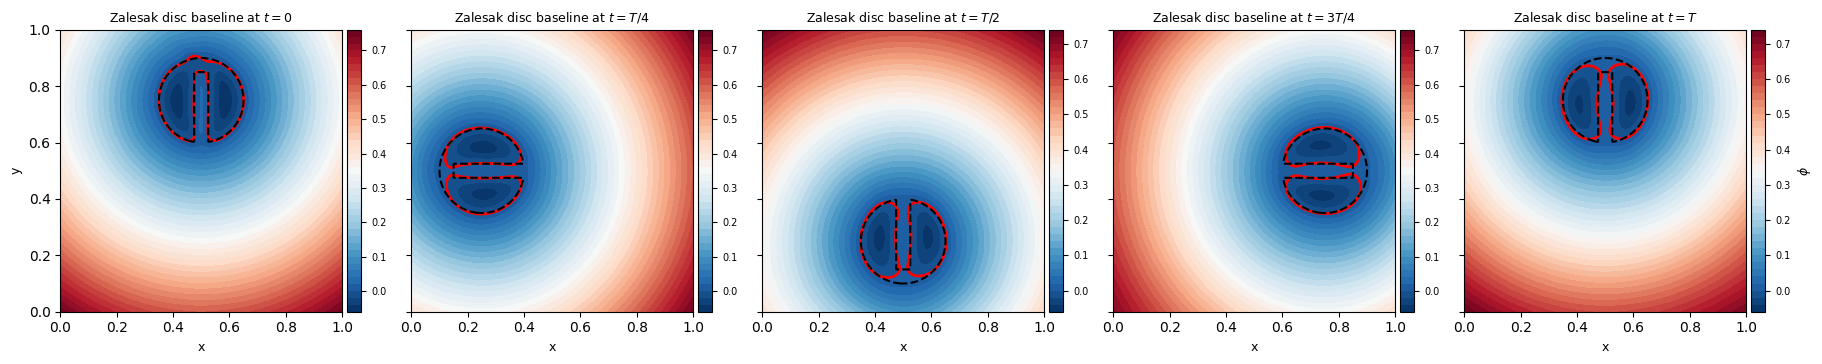

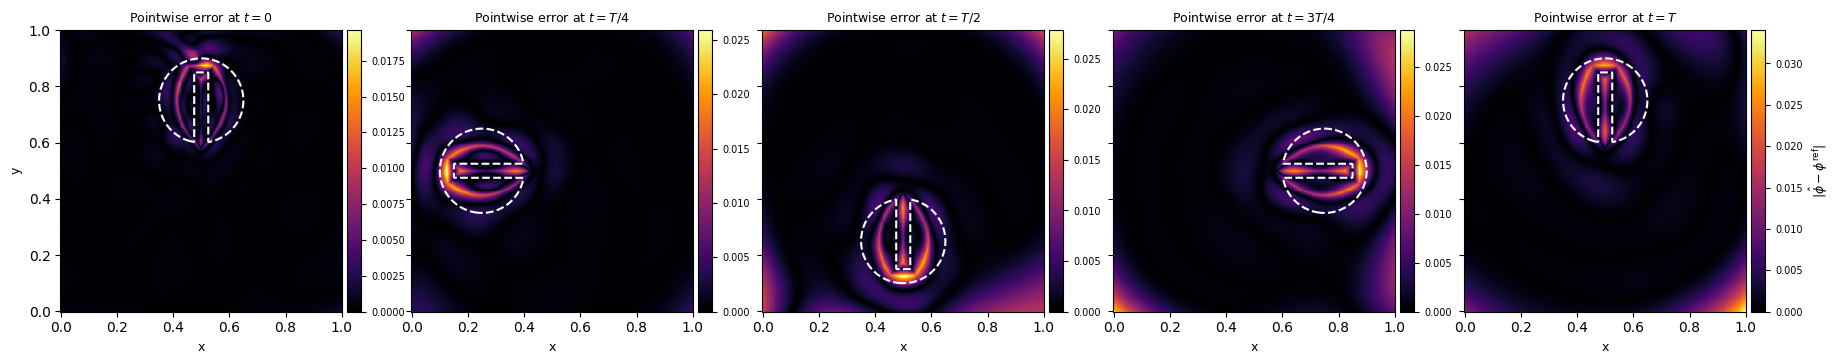


Snapshot           abs L2   rel L2 (%)     Mass err
--------------------------------------------------
t=0.00          1.11e-03        0.32%      2.24e-04
t=1.57          2.26e-03        0.65%      2.66e-03
t=3.14          3.40e-03        0.98%      2.66e-03
t=4.71          3.63e-03        1.04%      2.10e-03
t=6.28          3.94e-03        1.13%      1.92e-03
--------------------------------------------------
avg              2.87e-03        0.82%      1.91e-03


In [3]:
# ==============================================================
# CELL 4: VISUALIZATION
# Figure 1: phi field (1 row x 5 cols, per-snapshot colorbar)
# Figure 2: error field (1 row x 5 cols, per-snapshot colorbar)
# ==============================================================
import matplotlib.pyplot as plt
import numpy as np
import torch

times = [0.0, T_final/4, T_final/2, 3*T_final/4, T_final]
nx = 300

x_1d = np.linspace(0, 1, nx)
y_1d = np.linspace(0, 1, nx)
X, Y = np.meshgrid(x_1d, y_1d)
dx = dy = x_1d[1] - x_1d[0]

def exact_phi_rotated(X, Y, t):
    theta = 2 * np.pi * t / T_final
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    x0, y0 = 0.5, 0.5
    dx_c = XC - x0;  dy_c = YC - y0
    XC_t = x0 + cos_t*dx_c - sin_t*dy_c
    YC_t = y0 + sin_t*dx_c + cos_t*dy_c
    dX = X - XC_t;  dY = Y - YC_t
    X_loc =  cos_t*dX + sin_t*dY
    Y_loc = -sin_t*dX + cos_t*dY
    phi_circle = np.sqrt(dX**2 + dY**2) - R
    slot_x = np.abs(X_loc) - W
    slot_y = np.abs(Y_loc - (SLOT_YCENTER - YC)) - L
    phi_slot = np.maximum(slot_x, slot_y)
    return np.maximum(phi_circle, -phi_slot)

# Collect data
phi_preds, phi_refs = [], []
l2_abs_list, l2_rel_list, mass_abs_list = [], [], []

for t_val in times:
    t_norm = t_val / T_final
    XYT = torch.tensor(
        np.stack([X.flatten(), Y.flatten(),
                  t_norm * np.ones(X.size)], axis=1),
        dtype=torch.float32, device=device)
    with torch.no_grad():
        phi_pred = model(XYT).cpu().numpy().reshape(nx, nx)
    phi_ref = exact_phi_rotated(X, Y, t_val)
    phi_preds.append(phi_pred)
    phi_refs.append(phi_ref)

    l2_abs = np.sqrt(np.mean((phi_pred - phi_ref)**2))
    l2_rel = np.sqrt(np.sum((phi_pred - phi_ref)**2)) / np.sqrt(np.sum(phi_ref**2)) * 100
    mass_pred = np.sum(phi_pred < 0) * dx * dy
    mass_ref  = np.sum(phi_ref  < 0) * dx * dy
    mass_abs  = abs(mass_pred - mass_ref)

    l2_abs_list.append(l2_abs)
    l2_rel_list.append(l2_rel)
    mass_abs_list.append(mass_abs)

errors = [np.abs(phi_preds[i] - phi_refs[i]) for i in range(5)]
tlabels = ['t=0', 't=T/4', 't=T/2', 't=3T/4', 't=T']

from mpl_toolkits.axes_grid1 import ImageGrid

# ══════════════════════════════════════════════════════
# Figure 1: Predicted φ field
# ══════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(22, 5))
grid1 = ImageGrid(fig1, 111, nrows_ncols=(1, 5), axes_pad=0.5,
                  cbar_mode='each', cbar_location='right',
                  cbar_pad=0.05, cbar_size='5%')

for i, ax in enumerate(grid1):
    im = ax.contourf(X, Y, phi_preds[i], levels=50, cmap='RdBu_r')
    ax.contour(X, Y, phi_preds[i], levels=[0], colors='red',   linewidths=2)
    ax.contour(X, Y, phi_refs[i],  levels=[0], colors='black', linewidths=1.5,
               linestyles='--')
    ax.set_title(f'Zalesak disc baseline at ${tlabels[i]}$', fontsize=9)
    ax.set_aspect('equal')
    ax.set_xlabel('x', fontsize=9)
    if i == 0: ax.set_ylabel('y', fontsize=9)
    cb = grid1.cbar_axes[i].colorbar(im)
    cb.ax.tick_params(labelsize=7)
    if i == 4: cb.set_label(r'$\phi$', fontsize=9)   # ← only on last
#plt.savefig('/content/drive/MyDrive/fig_ZD_S3_exp01_phi.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ══════════════════════════════════════════════════════
# Figure 2: Pointwise error
# ══════════════════════════════════════════════════════
fig2 = plt.figure(figsize=(22, 5))
grid2 = ImageGrid(fig2, 111, nrows_ncols=(1, 5), axes_pad=0.5,
                  cbar_mode='each', cbar_location='right',
                  cbar_pad=0.05, cbar_size='5%')

for i, ax in enumerate(grid2):
    im = ax.pcolormesh(X, Y, errors[i], cmap='inferno',
                       vmin=0, vmax=errors[i].max(), shading='auto')
    ax.contour(X, Y, phi_refs[i], levels=[0], colors='white', linewidths=1.5,
               linestyles='--')
    ax.set_title(f'Pointwise error at ${tlabels[i]}$', fontsize=9)
    ax.set_aspect('equal')
    ax.set_xlabel('x', fontsize=9)
    if i == 0: ax.set_ylabel('y', fontsize=9)
    cb = grid2.cbar_axes[i].colorbar(im)
    cb.ax.tick_params(labelsize=7)
    if i == 4: cb.set_label(r'$|\hat{\phi}-\phi^{\rm ref}|$', fontsize=9)  # ← only on last
#plt.savefig('/content/drive/MyDrive/fig_ZD_S3_exp01_errors.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Summary
print(f"\n{'Snapshot':<12} {'abs L2':>12} {'rel L2 (%)':>12} {'Mass err':>12}")
print('-' * 50)
for t_val, l2a, l2r, me in zip(times, l2_abs_list, l2_rel_list, mass_abs_list):
    print(f't={t_val:<8.2f}  {l2a:>12.2e}  {l2r:>10.2f}%  {me:>12.2e}')
print('-' * 50)
print(f"{'avg':<12} {np.mean(l2_abs_list):>12.2e}  "
      f"{np.mean(l2_rel_list):>10.2f}%  {np.mean(mass_abs_list):>12.2e}")

In [4]:
import csv
import numpy as np

EXP_ID           = 'ZD_S3_exp01'
BENCHMARK        = 'ZD'
ARCHITECTURE     = 'plain_tanh_8x256'
SAMPLING         = 'IC_8.5k_uniform5k_bbox2k_walls1.5k_colloc_19k_uniform10k_slotwalls3k_bot3k_top3k_biased_t'
SCHEDULER        = 'StepLR'
SCHEDULER_PARAMS = 'step_1000_gamma_0.9'
T_NORMALIZED     = True
CSV_PATH         = '/content/drive/MyDrive/ZD_S3_architecture_study.csv'

row = {
    'exp_id':            EXP_ID,
    'benchmark':         BENCHMARK,
    'architecture':      ARCHITECTURE,
    'N_f':               N_f,
    'N_i':               N_i,
    'layers':            LAYERS,
    'neurons':           NEURONS,
    'n_fourier':         N_FOURIER,
    'b_scale':           B_SCALE,
    'causal':            False,
    'w_pde':             w_pde,
    'w_pde_slot':        w_pde_slot,
    'w_ic':              w_ic,
    'w_eik':             w_eik,
    'adam_epochs':       adam_epochs,
    'lbfgs_epochs':      lbfgs_epochs,
    'scheduler':         SCHEDULER,
    'scheduler_params':  SCHEDULER_PARAMS,
    'sampling':          SAMPLING,
    't_normalized':      T_NORMALIZED,
    # abs L2 per snapshot
    'L2abs_t0':          f'{l2_abs_list[0]:.2e}',
    'L2abs_tT4':         f'{l2_abs_list[1]:.2e}',
    'L2abs_tT2':         f'{l2_abs_list[2]:.2e}',
    'L2abs_t3T4':        f'{l2_abs_list[3]:.2e}',
    'L2abs_tT':          f'{l2_abs_list[4]:.2e}',
    'avg_L2abs':         f'{np.mean(l2_abs_list):.2e}',
    # rel L2 (%) per snapshot
    'L2rel(%)_t0':       f'{l2_rel_list[0]:.2f}%',
    'L2rel(%)_tT4':      f'{l2_rel_list[1]:.2f}%',
    'L2rel(%)_tT2':      f'{l2_rel_list[2]:.2f}%',
    'L2rel(%)_t3T4':     f'{l2_rel_list[3]:.2f}%',
    'L2rel(%)_tT':       f'{l2_rel_list[4]:.2f}%',
    'avg_L2rel(%)':      f'{np.mean(l2_rel_list):.2f}%',
    # mass error per snapshot
    'mass_t0':           f'{mass_abs_list[0]:.2e}',
    'mass_tT4':          f'{mass_abs_list[1]:.2e}',
    'mass_tT2':          f'{mass_abs_list[2]:.2e}',
    'mass_t3T4':         f'{mass_abs_list[3]:.2e}',
    'mass_tT':           f'{mass_abs_list[4]:.2e}',
    'avg_mass':          f'{np.mean(mass_abs_list):.2e}',
    'training_time':     checkpoint['training_time'],
}

write_header = False
try:
    with open(CSV_PATH, 'r') as f:
        write_header = (f.read(1) == '')
except FileNotFoundError:
    write_header = True

with open(CSV_PATH, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=row.keys())
    if write_header:
        writer.writeheader()
    writer.writerow(row)

print(f'Row appended → {CSV_PATH}')

Row appended → /content/drive/MyDrive/ZD_S3_architecture_study.csv
